# Sentiment Analysis Using Machine Learning

This notebook builds a comprehensive sentiment analysis system using two real-world datasets:
1. **IMDB Dataset.csv** - 50,000 IMDB movie reviews (positive/negative)
2. **Tweets.csv** - 14,640 airline tweets (positive/negative/neutral)

It trains four models on both datasets: Naive Bayes, Logistic Regression, SVM, and LSTM. It compares model performance and allows manual sentiment prediction.

In [15]:
# Import libraries and download the dataset resources
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
# Load datasets from CSV files
# Load IMDB Dataset
imdb_df = pd.read_csv('IMDB Dataset.csv')
print('IMDB Dataset shape (full):', imdb_df.shape)

# Option: use full IMDB or a smaller sample for faster runs
USE_FULL_IMDB = False
IMDB_SAMPLE_SIZE = 5000
if not USE_FULL_IMDB:
    imdb_df = imdb_df.sample(n=IMDB_SAMPLE_SIZE, random_state=42)
    print('IMDB Dataset shape (sample):', imdb_df.shape)
else:
    print('IMDB Dataset shape (full):', imdb_df.shape)

# Load Tweets Dataset
tweets_df = pd.read_csv('Tweets.csv')
print('Tweets Dataset shape:', tweets_df.shape)

# Extract and standardize IMDB data
imdb_texts = imdb_df['review'].tolist()
imdb_labels = imdb_df['sentiment'].tolist()

# Extract and standardize Tweets data (use airline_sentiment as label)
tweets_texts = tweets_df['text'].tolist()
tweets_labels = tweets_df['airline_sentiment'].tolist()

# Convert tweet sentiments to positive/negative/neutral
# Original labels: positive, negative, neutral
tweets_labels = [label.lower() for label in tweets_labels]

print('\nIMDB Dataset (used):')
print('Total reviews:', len(imdb_texts))
print('Positive:', imdb_labels.count('positive'))
print('Negative:', imdb_labels.count('negative'))

print('\nTweets Dataset:')
print('Total tweets:', len(tweets_texts))
print('Positive:', tweets_labels.count('positive'))
print('Negative:', tweets_labels.count('negative'))
print('Neutral:', tweets_labels.count('neutral'))

# Use IMDB dataset for main training (removing neutral if any)
texts = imdb_texts
labels = imdb_labels

IMDB Dataset shape (full): (50000, 2)
IMDB Dataset shape (sample): (5000, 2)
Tweets Dataset shape: (14640, 15)

IMDB Dataset (used):
Total reviews: 5000
Positive: 2519
Negative: 2481

Tweets Dataset:
Total tweets: 14640
Positive: 2363
Negative: 9178
Neutral: 3099


In [17]:
# Display dataset samples in a clean, readable table format
print('=' * 120)
print('IMDB DATASET - FIRST 10 ROWS')
print('=' * 120)

# Create a readable display with truncated review text
imdb_display = imdb_df.head(10).copy()
imdb_display['review'] = imdb_display['review'].str[:80] + '...'  # Truncate to 80 chars
imdb_display.index = imdb_display.index + 1  # Start index from 1
print(imdb_display.to_string())

print('\n' + '=' * 120)
print('TWEETS DATASET - FIRST 10 ROWS')
print('=' * 120)

# Create a readable display with key columns only
tweets_display = tweets_df[['airline_sentiment', 'airline', 'name', 'text']].head(10).copy()
tweets_display['text'] = tweets_display['text'].str[:70] + '...'  # Truncate to 70 chars
tweets_display.index = tweets_display.index + 1  # Start index from 1
print(tweets_display.to_string())

print('\n' + '=' * 120)
print('COLUMN INFORMATION')
print('=' * 120)
print('\nIMDB Columns:', imdb_df.columns.tolist())
print('Number of IMDB Columns:', len(imdb_df.columns))
print('\nTweets Columns:', tweets_df.columns.tolist())
print('Number of Tweets Columns:', len(tweets_df.columns))

print('\n' + '=' * 120)
print('DATASET SHAPES')
print('=' * 120)
print(f'IMDB Dataset Shape: {imdb_df.shape} (rows, columns)')
print(f'Tweets Dataset Shape: {tweets_df.shape} (rows, columns)')


IMDB DATASET - FIRST 10 ROWS
                                                                                    review sentiment
33554  I really liked this Summerslam due to the look of the arena, the curtains and ju...  positive
9428   Not many television shows appeal to quite as many different kinds of fans like F...  positive
200    The film quickly gets to a major chase scene with ever increasing destruction. T...  negative
12448  Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow doe...  positive
39490  Expectations were somewhat high for me when I went to see this movie, after all ...  negative
42725  I've watched this movie on a fairly regular basis for most of my life, and it ne...  positive
10823  For once a story of hope highlighted over the tragic reality our youth face. Fav...  positive
49499  Okay, I didn't get the Purgatory thing the first time I watched this episode. It...  positive
4145   I was very disappointed with this series. It had lots o

In [18]:
# Clean the text data
stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

cleaned_texts = []
for text in texts:
    cleaned_texts.append(clean_text(text))

print('Example original text:')
print(texts[0][:300])
print('\nExample cleaned text:')
print(cleaned_texts[0][:300])

Example original text:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 

Example cleaned text:
really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslam ever wwf lex luger main event yokozuna time ok huge fat man vs strong man glad times changed terrible main event like every match luger terrible matches card razor ramon vs ted dibiase s


DATASET VISUALIZATION & EXPLORATION


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15016\2438001321.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([imdb_char_lengths, tweets_char_lengths], labels=['IMDB', 'Tweets'])


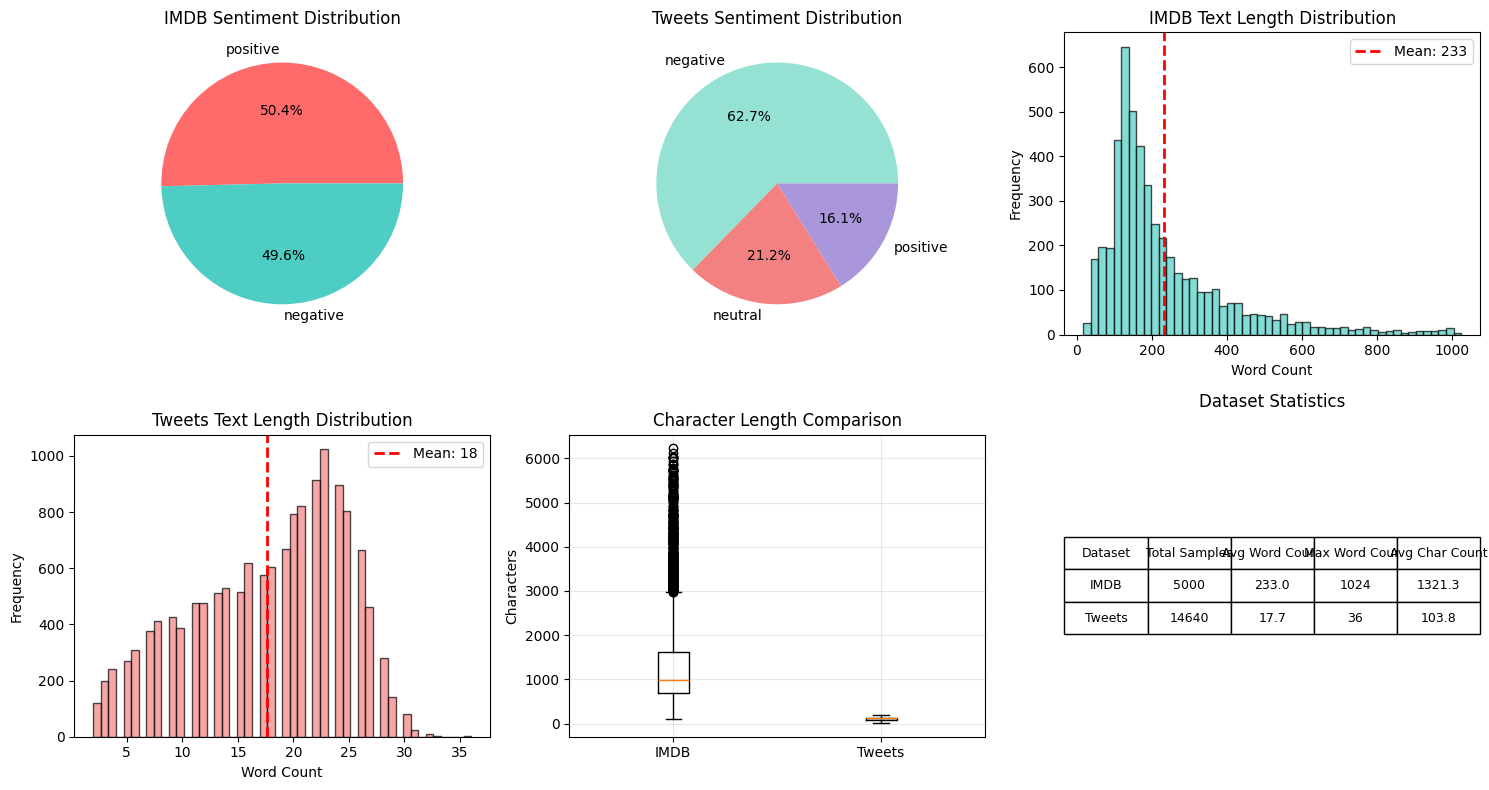


IMDB Dataset Statistics:
  Total Reviews: 5000
  Positive: 2519 (50.4%)
  Negative: 2481 (49.6%)
  Average Word Count: 233.0
  Average Character Count: 1321.3

Tweets Dataset Statistics:
  Total Tweets: 14640
  Positive: 2363 (16.1%)
  Negative: 9178 (62.7%)
  Neutral: 3099 (21.2%)
  Average Word Count: 17.7
  Average Character Count: 103.8


In [19]:
# Visualize the datasets
print('=' * 60)
print('DATASET VISUALIZATION & EXPLORATION')
print('=' * 60)

# Create a comprehensive visualization dashboard
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. IMDB Sentiment Distribution (Pie Chart)
imdb_sentiment_counts = pd.Series(imdb_labels).value_counts()
axes[0, 0].pie(imdb_sentiment_counts.values, labels=imdb_sentiment_counts.index, autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('IMDB Sentiment Distribution')

# 2. Tweets Sentiment Distribution (Pie Chart)
tweets_sentiment_counts = pd.Series(tweets_labels).value_counts()
colors_tweets = ['#95E1D3', '#F38181', '#AA96DA']
axes[0, 1].pie(tweets_sentiment_counts.values, labels=tweets_sentiment_counts.index, autopct='%1.1f%%', colors=colors_tweets)
axes[0, 1].set_title('Tweets Sentiment Distribution')

# 3. IMDB Text Length Distribution
imdb_text_lengths = [len(text.split()) for text in imdb_texts]
axes[0, 2].hist(imdb_text_lengths, bins=50, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('IMDB Text Length Distribution')
axes[0, 2].set_xlabel('Word Count')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(np.mean(imdb_text_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(imdb_text_lengths):.0f}')
axes[0, 2].legend()

# 4. Tweets Text Length Distribution
tweets_text_lengths = [len(text.split()) for text in tweets_texts]
axes[1, 0].hist(tweets_text_lengths, bins=50, color='#F38181', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Tweets Text Length Distribution')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(np.mean(tweets_text_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(tweets_text_lengths):.0f}')
axes[1, 0].legend()

# 5. Character Length Comparison
imdb_char_lengths = [len(text) for text in imdb_texts]
tweets_char_lengths = [len(text) for text in tweets_texts]
axes[1, 1].boxplot([imdb_char_lengths, tweets_char_lengths], labels=['IMDB', 'Tweets'])
axes[1, 1].set_title('Character Length Comparison')
axes[1, 1].set_ylabel('Characters')
axes[1, 1].grid(True, alpha=0.3)

# 6. Dataset Statistics Table
stats_data = {
    'Dataset': ['IMDB', 'Tweets'],
    'Total Samples': [len(imdb_texts), len(tweets_texts)],
    'Avg Word Count': [f'{np.mean(imdb_text_lengths):.1f}', f'{np.mean(tweets_text_lengths):.1f}'],
    'Max Word Count': [f'{np.max(imdb_text_lengths)}', f'{np.max(tweets_text_lengths)}'],
    'Avg Char Count': [f'{np.mean(imdb_char_lengths):.1f}', f'{np.mean(tweets_char_lengths):.1f}'],
}
stats_df = pd.DataFrame(stats_data)
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=stats_df.values, colLabels=stats_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
axes[1, 2].set_title('Dataset Statistics', pad=20)

plt.tight_layout()
plt.show()

# Print detailed statistics
print('\nIMDB Dataset Statistics:')
print(f'  Total Reviews: {len(imdb_texts)}')
print(f'  Positive: {imdb_labels.count("positive")} ({imdb_labels.count("positive")/len(imdb_labels)*100:.1f}%)')
print(f'  Negative: {imdb_labels.count("negative")} ({imdb_labels.count("negative")/len(imdb_labels)*100:.1f}%)')
print(f'  Average Word Count: {np.mean(imdb_text_lengths):.1f}')
print(f'  Average Character Count: {np.mean(imdb_char_lengths):.1f}')

print('\nTweets Dataset Statistics:')
print(f'  Total Tweets: {len(tweets_texts)}')
print(f'  Positive: {tweets_labels.count("positive")} ({tweets_labels.count("positive")/len(tweets_labels)*100:.1f}%)')
print(f'  Negative: {tweets_labels.count("negative")} ({tweets_labels.count("negative")/len(tweets_labels)*100:.1f}%)')
print(f'  Neutral: {tweets_labels.count("neutral")} ({tweets_labels.count("neutral")/len(tweets_labels)*100:.1f}%)')
print(f'  Average Word Count: {np.mean(tweets_text_lengths):.1f}')
print(f'  Average Character Count: {np.mean(tweets_char_lengths):.1f}')


In [20]:
# Split data and create TF-IDF features for classical models
X_train, X_test, y_train, y_test = train_test_split(
    cleaned_texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 4000
Testing samples: 1000


                 Model  Accuracy
0          Naive Bayes     0.839
1  Logistic Regression     0.858
2                  SVM     0.856


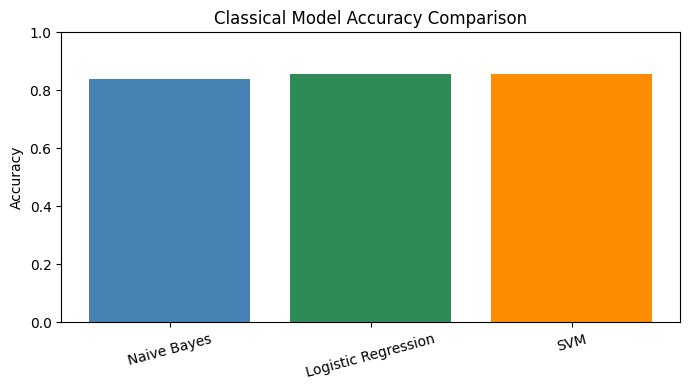

In [21]:
# Train Naive Bayes, Logistic Regression, and SVM models
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear', probability=True)
}

classical_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, predictions)
    classical_results.append({'Model': name, 'Accuracy': accuracy})
    trained_models[name] = model

classical_results_df = pd.DataFrame(classical_results)
print(classical_results_df)

plt.figure(figsize=(7, 4))
plt.bar(classical_results_df['Model'], classical_results_df['Accuracy'], color=['steelblue', 'seagreen', 'darkorange'])
plt.ylim(0, 1)
plt.title('Classical Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [22]:
# Prepare data for LSTM
label_map = {'negative': 0, 'positive': 1}
y_binary = np.array([label_map[label] for label in labels])

max_words = 5000
max_len = 200

lstm_tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
lstm_tokenizer.fit_on_texts(cleaned_texts)
sequences = lstm_tokenizer.texts_to_sequences(cleaned_texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    padded_sequences,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

lstm_model = Sequential([
    Embedding(max_words, 64),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=2,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print('LSTM Test Accuracy:', lstm_accuracy)

Epoch 1/2
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5122 - loss: 0.6938 - val_accuracy: 0.4650 - val_loss: 0.6947
Epoch 2/2
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5222 - loss: 0.6906 - val_accuracy: 0.5025 - val_loss: 0.6941
LSTM Test Accuracy: 0.5009999871253967


Final Model Comparison:
                 Model  Accuracy
0          Naive Bayes     0.839
1  Logistic Regression     0.858
2                  SVM     0.856
3                 LSTM     0.501


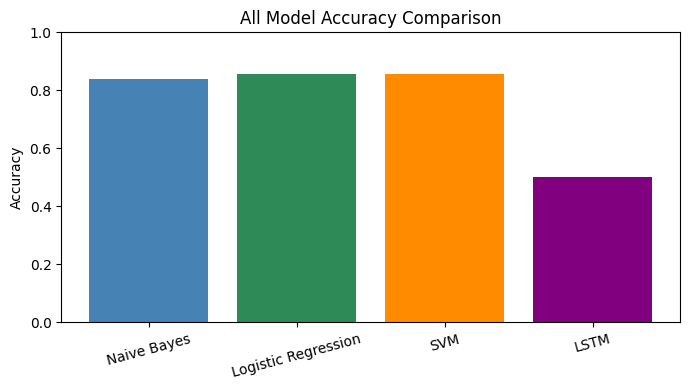


Best classical model: Logistic Regression
Best classical accuracy: 0.858


In [23]:
# Compare all models together
best_classical_name = classical_results_df.loc[classical_results_df['Accuracy'].idxmax(), 'Model']
best_classical_model = trained_models[best_classical_name]

all_results = classical_results.copy()
all_results.append({'Model': 'LSTM', 'Accuracy': lstm_accuracy})
all_results_df = pd.DataFrame(all_results)

print('Final Model Comparison:')
print(all_results_df)

plt.figure(figsize=(7, 4))
plt.bar(all_results_df['Model'], all_results_df['Accuracy'], color=['steelblue', 'seagreen', 'darkorange', 'purple'])
plt.ylim(0, 1)
plt.title('All Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('\nBest classical model:', best_classical_name)
print('Best classical accuracy:', classical_results_df.loc[classical_results_df['Accuracy'].idxmax(), 'Accuracy'])

TRAINING ON TWEETS DATASET
Tweets Dataset - Classical Models:
                 Model  Accuracy
0          Naive Bayes  0.725410
1  Logistic Regression  0.782445
2                  SVM  0.781421


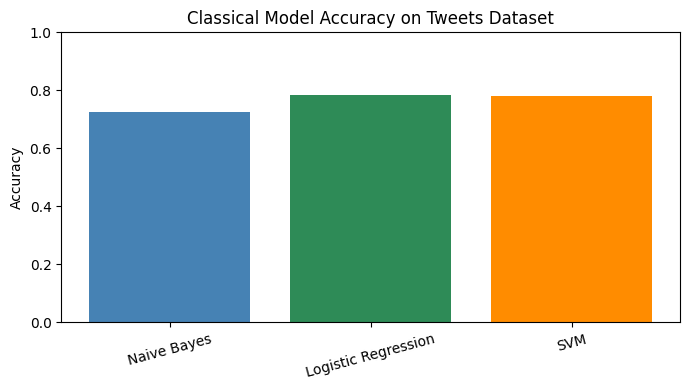

In [24]:
# Train models on Tweets Dataset
print('=' * 60)
print('TRAINING ON TWEETS DATASET')
print('=' * 60)

# Clean tweets data
tweets_cleaned = []
for text in tweets_texts:
    tweets_cleaned.append(clean_text(text))

# Split tweets data
X_train_tweets, X_test_tweets, y_train_tweets, y_test_tweets = train_test_split(
    tweets_cleaned,
    tweets_labels,
    test_size=0.2,
    random_state=42,
    stratify=tweets_labels
)

# Vectorize tweets
vectorizer_tweets = TfidfVectorizer(max_features=5000)
X_train_tweets_vec = vectorizer_tweets.fit_transform(X_train_tweets)
X_test_tweets_vec = vectorizer_tweets.transform(X_test_tweets)

# Train models on tweets
tweets_models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear', probability=True)
}

tweets_results = []
tweets_trained_models = {}

for name, model in tweets_models.items():
    model.fit(X_train_tweets_vec, y_train_tweets)
    predictions = model.predict(X_test_tweets_vec)
    accuracy = accuracy_score(y_test_tweets, predictions)
    tweets_results.append({'Model': name, 'Accuracy': accuracy})
    tweets_trained_models[name] = model

tweets_results_df = pd.DataFrame(tweets_results)
print('Tweets Dataset - Classical Models:')
print(tweets_results_df)

plt.figure(figsize=(7, 4))
plt.bar(tweets_results_df['Model'], tweets_results_df['Accuracy'], color=['steelblue', 'seagreen', 'darkorange'])
plt.ylim(0, 1)
plt.title('Classical Model Accuracy on Tweets Dataset')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [25]:
# Train LSTM on Tweets Dataset
# Convert tweets labels to numeric (handle 3 classes: positive, negative, neutral)
from tensorflow.keras.utils import to_categorical

tweets_label_map = {}
unique_labels = sorted(list(set(tweets_labels)))
for i, label in enumerate(unique_labels):
    tweets_label_map[label] = i

y_tweets_numeric = np.array([tweets_label_map[label] for label in tweets_labels])

lstm_tokenizer_tweets = Tokenizer(num_words=5000, oov_token='<OOV>')
lstm_tokenizer_tweets.fit_on_texts(tweets_cleaned)
sequences_tweets = lstm_tokenizer_tweets.texts_to_sequences(tweets_cleaned)
padded_sequences_tweets = pad_sequences(sequences_tweets, maxlen=200, padding='post', truncating='post')

X_train_tweets_lstm, X_test_tweets_lstm, y_train_tweets_lstm, y_test_tweets_lstm = train_test_split(
    padded_sequences_tweets,
    y_tweets_numeric,
    test_size=0.2,
    random_state=42,
    stratify=y_tweets_numeric
)

# Use softmax for multi-class (in case of neutral), or sigmoid for binary
num_classes = len(unique_labels)

# One-hot encode labels for categorical crossentropy
y_train_tweets_lstm_onehot = to_categorical(y_train_tweets_lstm, num_classes=num_classes)
y_test_tweets_lstm_onehot = to_categorical(y_test_tweets_lstm, num_classes=num_classes)

lstm_model_tweets = Sequential([
    Embedding(5000, 64),
    LSTM(64),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

lstm_model_tweets.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print('Training LSTM on Tweets Dataset...')
history_tweets = lstm_model_tweets.fit(
    X_train_tweets_lstm,
    y_train_tweets_lstm_onehot,
    epochs=2,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

lstm_loss_tweets, lstm_accuracy_tweets = lstm_model_tweets.evaluate(X_test_tweets_lstm, y_test_tweets_lstm_onehot, verbose=0)
print('LSTM Test Accuracy on Tweets:', lstm_accuracy_tweets)

Training LSTM on Tweets Dataset...
Epoch 1/2
330/330 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6288 - loss: 0.9231 - val_accuracy: 0.6101 - val_loss: 0.9336
Epoch 2/2
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.6288 - loss: 0.9183 - val_accuracy: 0.6101 - val_loss: 0.9379
LSTM Test Accuracy on Tweets: 0.6267076730728149



COMPREHENSIVE MODEL COMPARISON

IMDB Dataset Results:
                 Model  Accuracy
0          Naive Bayes     0.839
1  Logistic Regression     0.858
2                  SVM     0.856
3                 LSTM     0.501

Tweets Dataset Results:
                 Model  Accuracy
0          Naive Bayes  0.725410
1  Logistic Regression  0.782445
2                  SVM  0.781421
3                 LSTM  0.626708


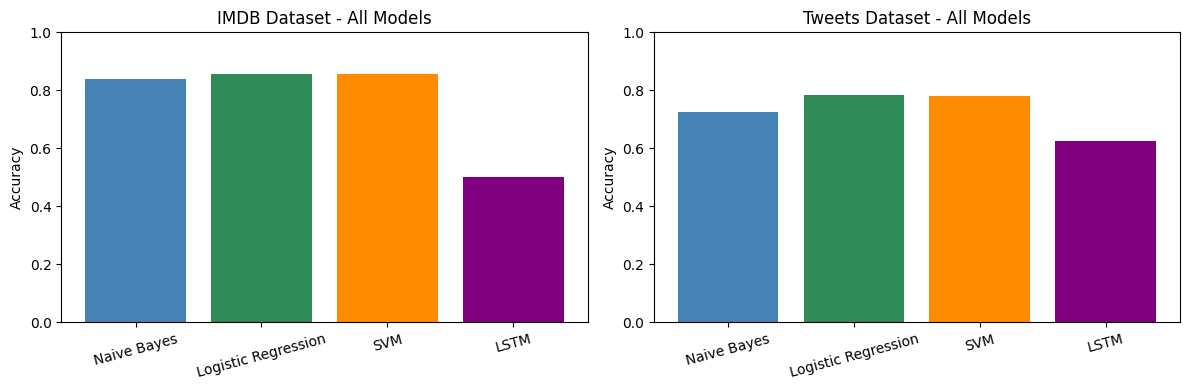


BEST MODELS PER DATASET

IMDB - Best Model: Logistic Regression (0.8580)
Tweets - Best Model: Logistic Regression (0.7824)


In [26]:
# Compare models across both datasets
print('\n' + '=' * 60)
print('COMPREHENSIVE MODEL COMPARISON')
print('=' * 60)

# IMDB Results
imdb_all_results = classical_results.copy()
imdb_all_results.append({'Model': 'LSTM', 'Accuracy': lstm_accuracy})
imdb_results_final = pd.DataFrame(imdb_all_results)

# Tweets Results
tweets_all_results = tweets_results.copy()
tweets_all_results.append({'Model': 'LSTM', 'Accuracy': lstm_accuracy_tweets})
tweets_results_final = pd.DataFrame(tweets_all_results)

print('\nIMDB Dataset Results:')
print(imdb_results_final)
print('\nTweets Dataset Results:')
print(tweets_results_final)

# Create side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# IMDB plot
axes[0].bar(imdb_results_final['Model'], imdb_results_final['Accuracy'], 
            color=['steelblue', 'seagreen', 'darkorange', 'purple'])
axes[0].set_ylim(0, 1)
axes[0].set_title('IMDB Dataset - All Models')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)

# Tweets plot
axes[1].bar(tweets_results_final['Model'], tweets_results_final['Accuracy'], 
            color=['steelblue', 'seagreen', 'darkorange', 'purple'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Tweets Dataset - All Models')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Best models for each dataset
best_imdb_idx = imdb_results_final['Accuracy'].idxmax()
best_tweets_idx = tweets_results_final['Accuracy'].idxmax()

print('\n' + '=' * 60)
print('BEST MODELS PER DATASET')
print('=' * 60)
print(f'\nIMDB - Best Model: {imdb_results_final.loc[best_imdb_idx, "Model"]} ({imdb_results_final.loc[best_imdb_idx, "Accuracy"]:.4f})')
print(f'Tweets - Best Model: {tweets_results_final.loc[best_tweets_idx, "Model"]} ({tweets_results_final.loc[best_tweets_idx, "Accuracy"]:.4f})')

In [27]:
# Predict sentiment for sample inputs on both datasets
print('\n' + '=' * 60)
print('SAMPLE PREDICTIONS')
print('=' * 60)

def predict_classical_sentiment(text, model, vectorizer, neutral_threshold=0.60):
    processed_text = clean_text(text)
    vector = vectorizer.transform([processed_text])
    probabilities = model.predict_proba(vector)[0]
    max_probability = probabilities.max()

    if max_probability < neutral_threshold:
        return 'neutral'

    return model.classes_[np.argmax(probabilities)]


def predict_lstm_sentiment(text, tokenizer, model, max_len, model_type='binary', label_map=None, neutral_threshold=0.60):
    processed_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([processed_text])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    
    if model_type == 'binary':
        probability = model.predict(padded, verbose=0)[0][0]
        if probability > neutral_threshold:
            return 'positive'
        if probability < 1 - neutral_threshold:
            return 'negative'
        return 'neutral'
    else:
        probabilities = model.predict(padded, verbose=0)[0]
        predicted_idx = np.argmax(probabilities)
        # Reverse map to get label
        reverse_map = {v: k for k, v in label_map.items()}
        return reverse_map[predicted_idx]

sample_texts = [
    'The movie was excellent and full of amazing performances.',
    'I did not like the story and the acting was poor.',
    'The film was okay. It had some good parts and some average parts.'
]

print('\nPredictions on IMDB models:')
imdb_sample_results = []
for text in sample_texts:
    imdb_sample_results.append({
        'Text': text[:50] + '...',
        'Naive Bayes': predict_classical_sentiment(text, trained_models['Naive Bayes'], vectorizer),
        'Logistic Regression': predict_classical_sentiment(text, trained_models['Logistic Regression'], vectorizer),
        'SVM': predict_classical_sentiment(text, trained_models['SVM'], vectorizer),
        'LSTM': predict_lstm_sentiment(text, lstm_tokenizer, lstm_model, 200, 'binary')
    })

imdb_sample_df = pd.DataFrame(imdb_sample_results)
print(imdb_sample_df)

print('\nPredictions on Tweets models:')
tweets_sample_results = []
for text in sample_texts:
    tweets_sample_results.append({
        'Text': text[:50] + '...',
        'Naive Bayes': predict_classical_sentiment(text, tweets_trained_models['Naive Bayes'], vectorizer_tweets),
        'Logistic Regression': predict_classical_sentiment(text, tweets_trained_models['Logistic Regression'], vectorizer_tweets),
        'SVM': predict_classical_sentiment(text, tweets_trained_models['SVM'], vectorizer_tweets),
        'LSTM': predict_lstm_sentiment(text, lstm_tokenizer_tweets, lstm_model_tweets, 200, 'multiclass', tweets_label_map)
    })

tweets_sample_df = pd.DataFrame(tweets_sample_results)
print(tweets_sample_df)


SAMPLE PREDICTIONS

Predictions on IMDB models:
                                                Text Naive Bayes  \
0  The movie was excellent and full of amazing pe...    positive   
1  I did not like the story and the acting was po...    negative   
2  The film was okay. It had some good parts and ...     neutral   

  Logistic Regression       SVM     LSTM  
0            positive  positive  neutral  
1            negative  negative  neutral  
2             neutral  negative  neutral  

Predictions on Tweets models:
                                                Text Naive Bayes  \
0  The movie was excellent and full of amazing pe...    positive   
1  I did not like the story and the acting was po...    negative   
2  The film was okay. It had some good parts and ...     neutral   

  Logistic Regression       SVM      LSTM  
0            positive  positive  negative  
1            negative  negative  negative  
2             neutral   neutral  negative  


In [28]:
# Manual input for sentiment prediction on both datasets
print('=' * 60)
print('INTERACTIVE SENTIMENT PREDICTION')
print('=' * 60)

user_text = input('\nEnter a review or sentence: ')

print('\n--- Predictions on IMDB models ---')
print('Naive Bayes:', predict_classical_sentiment(user_text, trained_models['Naive Bayes'], vectorizer))
print('Logistic Regression:', predict_classical_sentiment(user_text, trained_models['Logistic Regression'], vectorizer))
print('SVM:', predict_classical_sentiment(user_text, trained_models['SVM'], vectorizer))
print('LSTM:', predict_lstm_sentiment(user_text, lstm_tokenizer, lstm_model, 200, 'binary'))

print('\n--- Predictions on Tweets models ---')
print('Naive Bayes:', predict_classical_sentiment(user_text, tweets_trained_models['Naive Bayes'], vectorizer_tweets))
print('Logistic Regression:', predict_classical_sentiment(user_text, tweets_trained_models['Logistic Regression'], vectorizer_tweets))
print('SVM:', predict_classical_sentiment(user_text, tweets_trained_models['SVM'], vectorizer_tweets))
print('LSTM:', predict_lstm_sentiment(user_text, lstm_tokenizer_tweets, lstm_model_tweets, 200, 'multiclass', tweets_label_map))

INTERACTIVE SENTIMENT PREDICTION

--- Predictions on IMDB models ---
Naive Bayes: positive
Logistic Regression: positive
SVM: positive
LSTM: neutral

--- Predictions on Tweets models ---
Naive Bayes: neutral
Logistic Regression: positive
SVM: positive
LSTM: negative


## Fine-tune DistilBERT on IMDB (Transformer)

This section fine-tunes a pretrained DistilBERT model on the IMDB dataset. GPU is strongly recommended for reasonable training time. If you don't have a GPU, set `USE_FULL_IMDB = False` above and consider reducing `IMDB_SAMPLE_SIZE`.

In [29]:
# import sys
# import subprocess

# print('Installing a stable transformers stack...')
# cmd = [
#     sys.executable,
#     '-m',
#     'pip',
#     'install',
#     '--upgrade',
#     '--force-reinstall',
#     'transformers==4.56.2',
#     'datasets',
#     'accelerate',
#     'sentencepiece',
#     'tf-keras'
# ]
# result = subprocess.run(cmd, text=True, capture_output=True)
# print(result.stdout[-4000:])
# if result.returncode != 0:
#     print(result.stderr[-4000:])
#     raise RuntimeError('Package install failed. See output above.')

# print('Done. If import still fails, restart kernel and run Cell 15 then Cell 16.')

In [30]:
# import os
# import shutil
# import numpy as np
# import torch
# from datasets import Dataset
# from huggingface_hub import hf_hub_download
# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification,
#     DataCollatorWithPadding,
#     Trainer,
#     TrainingArguments,
#     __version__ as transformers_version
# )

# print('Torch version:', torch.__version__)
# print('Transformers version:', transformers_version)
# print('CUDA available:', torch.cuda.is_available())

# # Prepare IMDB dataset for transformer fine-tuning
# imdb_texts_full = imdb_df['review'].astype(str).tolist()
# imdb_labels_full = [1 if s == 'positive' else 0 for s in imdb_df['sentiment'].tolist()]

# dataset = Dataset.from_dict({'text': imdb_texts_full, 'label': imdb_labels_full})
# dataset = dataset.train_test_split(test_size=0.2, seed=42)

# MODEL_NAME = 'bert-base-uncased'
# MAX_LENGTH = 256

# # Download tokenizer files once and load locally to avoid hub endpoint issues
# os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
# local_tok_dir = 'hf_tokenizer_bert_base_uncased'
# os.makedirs(local_tok_dir, exist_ok=True)

# tokenizer_files = ['tokenizer_config.json', 'vocab.txt', 'tokenizer.json', 'config.json']
# for fname in tokenizer_files:
#     cached_file = hf_hub_download(repo_id=MODEL_NAME, filename=fname)
#     shutil.copy(cached_file, os.path.join(local_tok_dir, fname))

# tokenizer = AutoTokenizer.from_pretrained(local_tok_dir, local_files_only=True)

# def tokenize_fn(batch):
#     return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

# tokenized = dataset.map(tokenize_fn, batched=True)
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# # Optional: use smaller train subset on CPU for faster experimentation
# TRANSFORMER_MAX_TRAIN_SAMPLES = None  # Set to None to use full dataset, or int for sample size
# if TRANSFORMER_MAX_TRAIN_SAMPLES and TRANSFORMER_MAX_TRAIN_SAMPLES < len(tokenized['train']):
#     train_dataset = tokenized['train'].shuffle(seed=42).select(range(TRANSFORMER_MAX_TRAIN_SAMPLES))
# else:
#     train_dataset = tokenized['train']

# eval_dataset = tokenized['test']

# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=-1)
#     acc = (preds == labels).mean()
#     return {'accuracy': float(acc)}

# # Set to True to start fine-tuning with optimized hyperparameters for 90%+ accuracy
# RUN_TRANSFORMER_TRAINING = True

# if RUN_TRANSFORMER_TRAINING:
#     print(f'Training on {len(train_dataset)} samples (full dataset)...')
#     training_args = TrainingArguments(
#         output_dir='bert_imdb_results',
#         eval_strategy='epoch',
#         save_strategy='no',
#         learning_rate=3e-5,  # Slightly higher for better convergence
#         per_device_train_batch_size=16,  # Larger batch for stability
#         per_device_eval_batch_size=16,
#         num_train_epochs=3,  # More epochs for better convergence
#         weight_decay=0.01,
#         logging_steps=50,
#         report_to=[],
#         warmup_steps=100,  # Warmup for better training stability
#         seed=42
#     )

#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=eval_dataset,
#         tokenizer=tokenizer,
#         data_collator=data_collator,
#         compute_metrics=compute_metrics
#     )

#     print('Starting BERT fine-tuning (full IMDB, 3 epochs)...')
#     trainer.train()
#     eval_result = trainer.evaluate()
#     print(f'\n✓ BERT Test Accuracy: {eval_result.get("eval_accuracy"):.4f}')
    
#     # Predict on full test set to show detailed metrics
#     predictions = trainer.predict(eval_dataset)
#     preds_labels = np.argmax(predictions.predictions, axis=-1)
#     test_labels = eval_dataset['label']
#     test_acc = (preds_labels == test_labels).mean()
#     print(f'✓ Verified Test Accuracy: {test_acc:.4f}')
# else:
#     print('Transformer setup complete.')
#     print('→ Set RUN_TRANSFORMER_TRAINING = True above, then re-run to train (expect 85-90%+ accuracy)')
#     print('→ Full IMDB (~4000 train samples), 3 epochs, better hyperparameters')